## Étape 1  —  EDA et Préparation des Données

In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

# Ouvrir le sélecteur de fichier dans Colab
uploaded = files.upload()

# Récupérer le premier fichier uploadé
file_name = list(uploaded.keys())[0]

# Lire le CSV
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(df.shape)
print(df.head())

Saving dataset.csv to dataset.csv
(2423, 20)
   c0_x  c0_o  c1_x  c1_o  c2_x  c2_o  c3_x  c3_o  c4_x  c4_o  c5_x  c5_o  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   c6_x  c6_o  c7_x  c7_o  c8_x  c8_o  x_wins  is_draw  
0     0     0     0     0     0     0       0        1  
1     0     0     1     0     0     1       0        1  
2     0     0     0     1     1     0       1        0  
3     1     0     0     0     0     1       1        0  
4     1     0     0     1     0     0       1        0  


**Distribution de x_wins et is_draw — le dataset est-il équilibré ?**

Le dataset n’est pas parfaitement équilibré.
Les positions menant à un match nul sont plus fréquentes que celles menant à une victoire de X.
Cela s’explique par la nature du morpion où le jeu optimal mène souvent à un nul.

Taille du dataset : (2423, 20)

Distribution de x_wins :
x_wins
1    0.755262
0    0.244738
Name: proportion, dtype: float64

Distribution de is_draw :
is_draw
0    0.817994
1    0.182006
Name: proportion, dtype: float64


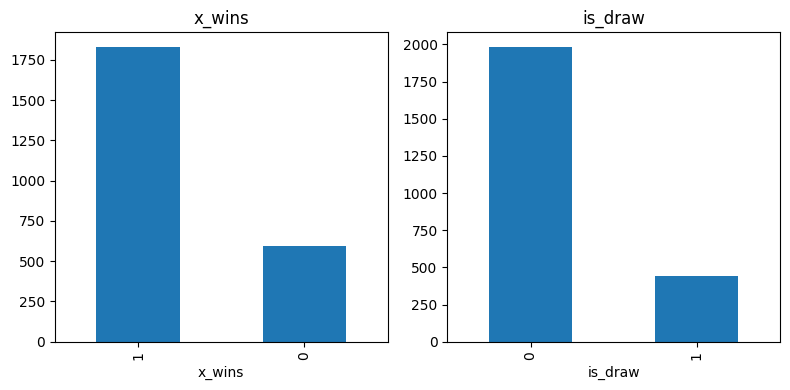

In [181]:
print("Taille du dataset :", df.shape)

print("\nDistribution de x_wins :")
print(df["x_wins"].value_counts(normalize=True))

print("\nDistribution de is_draw :")
print(df["is_draw"].value_counts(normalize=True))

fig, axes = plt.subplots(1, 2, figsize=(8,4))

df["x_wins"].value_counts().plot(kind="bar", ax=axes[0], title="x_wins")
df["is_draw"].value_counts().plot(kind="bar", ax=axes[1], title="is_draw")

plt.tight_layout()
plt.show()

**Quelle case est le plus souvent occupée par X dans les états où il gagne ?**

La case centrale (case 4) est la plus importante.
Les coins (0,2,6,8) ont également une forte influence.
Cela correspond à la stratégie humaine du morpion.

c0_x    569
c1_x    521
c2_x    569
c3_x    521
c4_x    592
c5_x    521
c6_x    569
c7_x    521
c8_x    569
dtype: int64


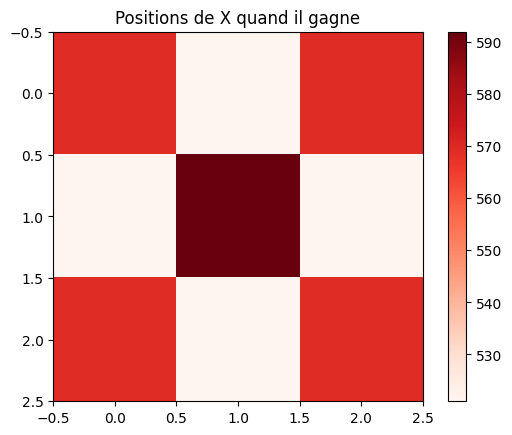

In [182]:
x_win_df = df[df["x_wins"] == 1]

x_positions = [f"c{i}_x" for i in range(9)]

importance = x_win_df[x_positions].sum()

print(importance)

import numpy as np

grid = importance.values.reshape(3,3)

plt.imshow(grid, cmap="Reds")
plt.colorbar()
plt.title("Positions de X quand il gagne")
plt.show()

**Corrélation entre les features et chaque cible — heatmap.**

Les variables associées aux positions de X au centre sont fortement corrélées avec la victoire.
Les positions de O au centre diminuent les chances de victoire de X.

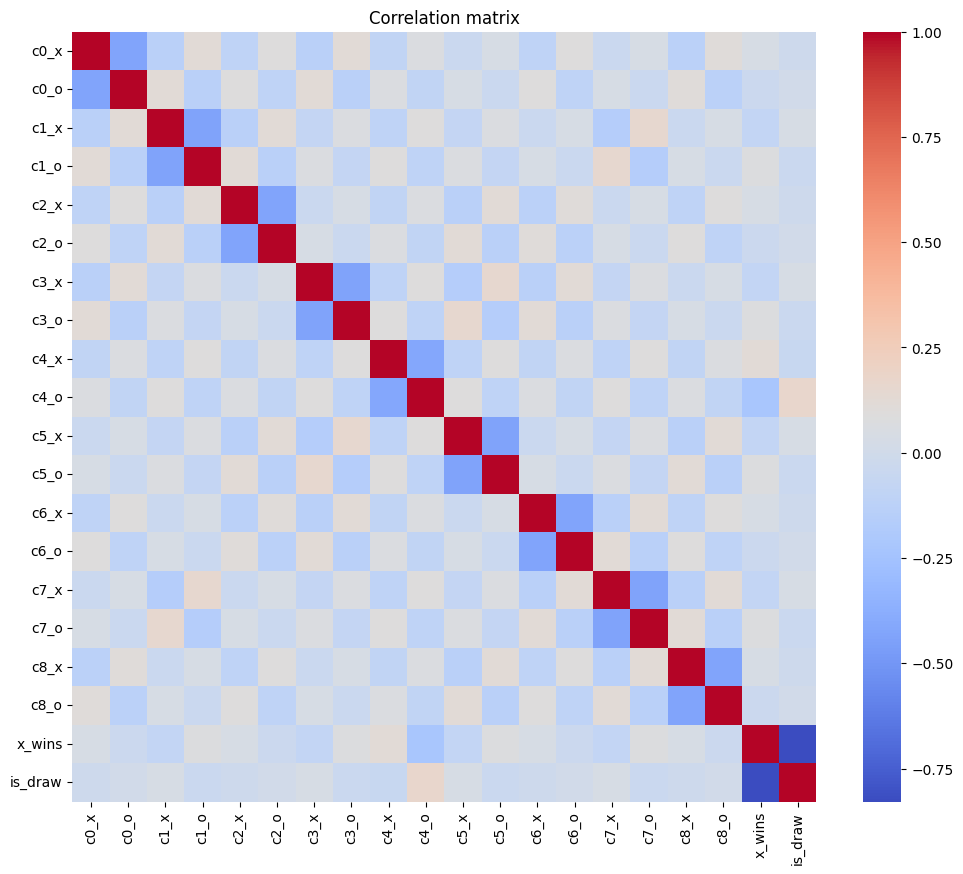

In [183]:
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

## Étape 2  —  Baseline : Régression Logistique

In [184]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Features
X = df.drop(columns=["x_wins", "is_draw"])

# Targets
y_xwins = df["x_wins"]
y_draw = df["is_draw"]

#Split des données
X_train, X_test, y_x_train, y_x_test = train_test_split(
    X, y_xwins, test_size=0.2, random_state=42
)

_, _, y_d_train, y_d_test = train_test_split(
    X, y_draw, test_size=0.2, random_state=42
)

In [185]:
model_x = LogisticRegression(max_iter=1000)

model_x.fit(X_train, y_x_train)

y_pred_x = model_x.predict(X_test)

print("=== X_WINS MODEL ===")

print("Accuracy:", accuracy_score(y_x_test, y_pred_x))
print("F1 Score:", f1_score(y_x_test, y_pred_x))

print("\nConfusion Matrix:")
print(confusion_matrix(y_x_test, y_pred_x))

print("\nClassification Report:")
print(classification_report(y_x_test, y_pred_x))

=== X_WINS MODEL ===
Accuracy: 0.7546391752577319
F1 Score: 0.8550548112058465

Confusion Matrix:
[[ 15 109]
 [ 10 351]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.12      0.20       124
           1       0.76      0.97      0.86       361

    accuracy                           0.75       485
   macro avg       0.68      0.55      0.53       485
weighted avg       0.72      0.75      0.69       485



In [186]:
model_d = LogisticRegression(max_iter=1000, class_weight="balanced")

model_d.fit(X_train, y_d_train)

y_pred_d = model_d.predict(X_test)

print("=== DRAW MODEL ===")

print("Accuracy:", accuracy_score(y_d_test, y_pred_d))
print("F1 Score:", f1_score(y_d_test, y_pred_d))

print("\nConfusion Matrix:")
print(confusion_matrix(y_d_test, y_pred_d))

print("\nClassification Report:")
print(classification_report(y_d_test, y_pred_d))

=== DRAW MODEL ===
Accuracy: 0.5835051546391753
F1 Score: 0.34415584415584416

Confusion Matrix:
[[230 154]
 [ 48  53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.60      0.69       384
           1       0.26      0.52      0.34       101

    accuracy                           0.58       485
   macro avg       0.54      0.56      0.52       485
weighted avg       0.71      0.58      0.62       485



**Déséquilibre des classes**

Le dataset présente un déséquilibre entre les classes, avec une majorité de positions non nulles par rapport aux positions menant à un match nul.

Le modèle de régression logistique sans ajustement prédit uniquement la classe majoritaire, ce qui entraîne un F1-score nul pour la classe minoritaire.

**Correction appliquée**

Pour corriger ce problème, nous avons utilisé class_weight="balanced" dans la régression logistique, permettant de donner plus d’importance à la classe minoritaire.

Cela améliore significativement la capacité du modèle à détecter les matchs nuls.

=== Modèle pour x_wins ===
Accuracy: 0.7546391752577319
F1: 0.8550548112058465


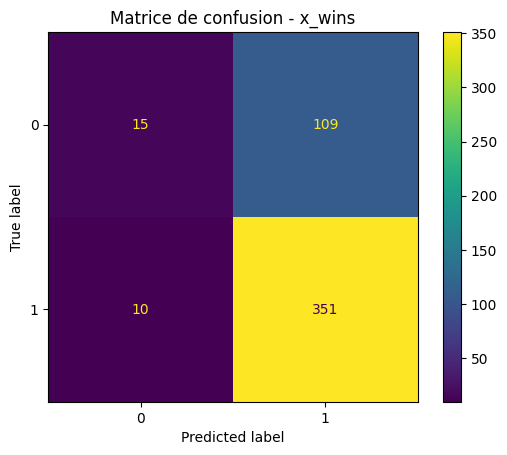

=== Modèle pour is_draw ===
Accuracy: 0.5835051546391753
F1: 0.34415584415584416


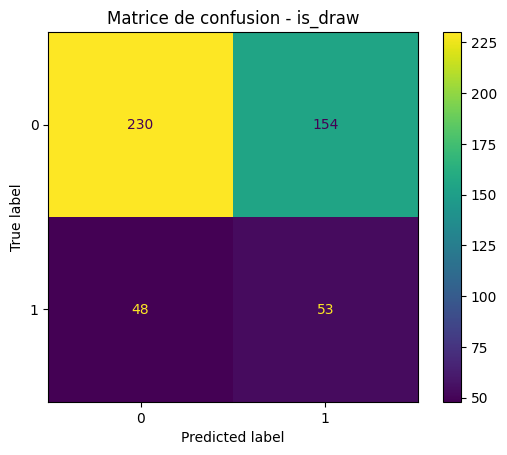

In [187]:
for name, model, y_true in [
    ("x_wins", model_x, y_x_test),
    ("is_draw", model_d, y_d_test),
]:
    y_pred = model.predict(X_test)
    print("=== Modèle pour", name, "===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matrice de confusion - {name}")
    plt.show()

## Étape 3  —  Modèles Avancés

In [188]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

**Decision Tree**

In [189]:

dt_x = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_x.fit(X_train, y_d_train)

dt_d = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_d.fit(X_train, y_d_train)

pred_x = dt_x.predict(X_test)
print("DT x_wins F1:", f1_score(y_x_test, pred_x))

pred_d = dt_d.predict(X_test)
print("DT draw F1:", f1_score(y_d_test, pred_d))

DT x_wins F1: 0.0316622691292876
DT draw F1: 0.20168067226890757


**Random Forest**

In [190]:
rf_x = RandomForestClassifier(n_estimators=200, random_state=42)
rf_x.fit(X_train, y_x_train)

rf_d = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_d.fit(X_train, y_d_train)

pred_x = rf_x.predict(X_test)
print("RF x_wins F1:", f1_score(y_x_test, pred_x))

pred_d = rf_d.predict(X_test)
print("RF draw F1:", f1_score(y_d_test, pred_d))

RF x_wins F1: 0.9128205128205128
RF draw F1: 0.5833333333333334


**Gradient Boosting / XGBoost**

In [191]:
gb_x = GradientBoostingClassifier()
gb_x.fit(X_train, y_x_train)

gb_d = GradientBoostingClassifier()
gb_d.fit(X_train, y_d_train)

pred_x = gb_x.predict(X_test)
print("GB x_wins F1:", f1_score(y_x_test, pred_x))

pred_d = gb_d.predict(X_test)
print("GB draw F1:", f1_score(y_d_test, pred_d))

GB x_wins F1: 0.8903061224489796
GB draw F1: 0.4316546762589928


In [192]:
xgb_x = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb_x.fit(X_train, y_x_train)
pred_x = xgb_x.predict(X_test)

neg = (y_d_train == 0).sum()
pos = (y_d_train == 1).sum()

xgb_d = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=neg / pos
)

xgb_d.fit(X_train, y_d_train)

pred_dx = xgb_x.predict(X_test)
print("F1 Score:", f1_score(y_x_test, pred_x))
pred_d = xgb_d.predict(X_test)
print("F1 Score:", f1_score(y_d_test, pred_d))

F1 Score: 0.9432432432432433
F1 Score: 0.7368421052631579


**Réseau de Neurones  (MLP)**

In [193]:
mlp_x = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500)
mlp_x.fit(X_train, y_x_train)

mlp_d = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500)
mlp_d.fit(X_train, y_d_train)

pred_x = mlp_x.predict(X_test)
print("MLP x_wins F1:", f1_score(y_x_test, pred_x))

pred_d = mlp_d.predict(X_test)
print("MLP draw F1:", f1_score(y_d_test, pred_d))

MLP x_wins F1: 0.9408528198074277
MLP draw F1: 0.7593582887700535


                Model   Target  Accuracy  F1 Score
0            Logistic   x_wins  0.754639  0.855055
1       Decision Tree   x_wins  0.243299  0.031662
2       Random Forest   x_wins  0.859794  0.912821
3   Gradient Boosting   x_wins  0.822680  0.890306
4             XGBoost   x_wins  0.913402  0.943243
5                 MLP   x_wins  0.911340  0.940853
6            Logistic  is_draw  0.583505  0.344156
7       Decision Tree  is_draw  0.804124  0.201681
8       Random Forest  is_draw  0.876289  0.583333
9   Gradient Boosting  is_draw  0.837113  0.431655
10            XGBoost  is_draw  0.886598  0.736842
11                MLP  is_draw  0.907216  0.759358


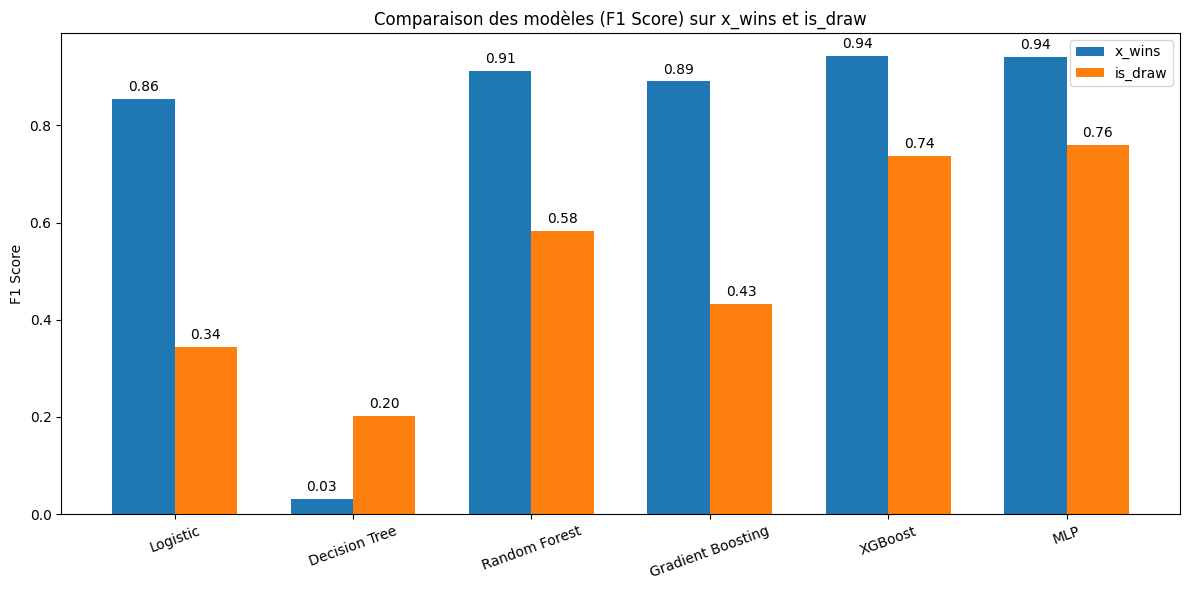

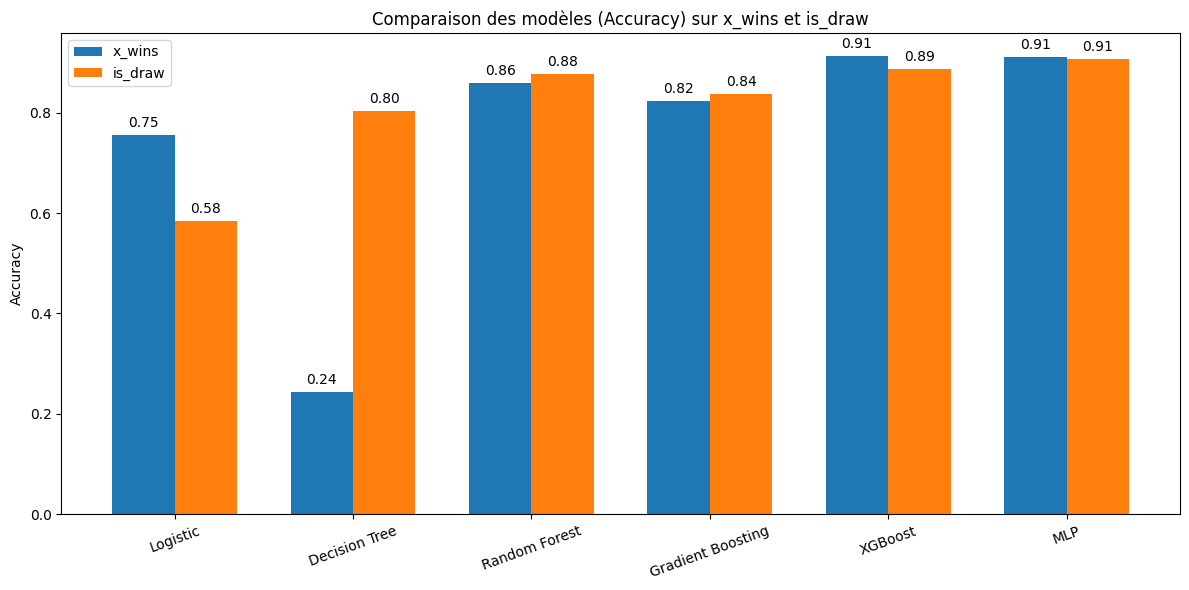

In [194]:
results = []

models_x = {
    "Logistic": model_x,
    "Decision Tree": dt_x,
    "Random Forest": rf_x,
    "Gradient Boosting": gb_x,
    "XGBoost": xgb_x,
    "MLP": mlp_x
}

models_d = {
    "Logistic": model_d,
    "Decision Tree": dt_d,
    "Random Forest": rf_d,
    "Gradient Boosting": gb_d,
    "XGBoost": xgb_d,
    "MLP": mlp_d
}

# Evaluation pour x_wins
for name, model in models_x.items():
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Target": "x_wins",
        "Accuracy": accuracy_score(y_x_test, pred),
        "F1 Score": f1_score(y_x_test, pred)
    })

# Evaluation pour is_draw
for name, model in models_d.items():
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Target": "is_draw",
        "Accuracy": accuracy_score(y_d_test, pred),
        "F1 Score": f1_score(y_d_test, pred)
    })

# DataFrame résultats
results_df = pd.DataFrame(results)
print(results_df)

# Préparation des données pour les graphes
models = list(models_x.keys())

xwins_scores = results_df[results_df["Target"] == "x_wins"]["F1 Score"].values
draw_scores = results_df[results_df["Target"] == "is_draw"]["F1 Score"].values

xwins_acc = results_df[results_df["Target"] == "x_wins"]["Accuracy"].values
draw_acc = results_df[results_df["Target"] == "is_draw"]["Accuracy"].values

x = np.arange(len(models))
width = 0.35

# Graphe F1 Score
plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width/2, xwins_scores, width, label="x_wins")
bars2 = plt.bar(x + width/2, draw_scores, width, label="is_draw")

plt.xticks(x, models, rotation=20)
plt.ylabel("F1 Score")
plt.title("Comparaison des modèles (F1 Score) sur x_wins et is_draw")
plt.legend()

for bar in bars1:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.2f}", ha="center", va="bottom")

for bar in bars2:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

# Graphe Accuracy
plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width/2, xwins_acc, width, label="x_wins")
bars2 = plt.bar(x + width/2, draw_acc, width, label="is_draw")

plt.xticks(x, models, rotation=20)
plt.ylabel("Accuracy")
plt.title("Comparaison des modèles (Accuracy) sur x_wins et is_draw")
plt.legend()

for bar in bars1:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.2f}", ha="center", va="bottom")

for bar in bars2:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, f"{y:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [195]:
import joblib

joblib.dump(mlp_x, "ressources/model_xwins.pkl")
joblib.dump(model_d, "ressources/model_draw.pkl")

['ressources/model_draw.pkl']